# Are deceptive priors "closer to the optimum" on lm1b?

**Theory.** Deceptive priors are caught less often on `lm1b_transformer_2048` because the
clusters they are drawn from sit closer (in configuration space) to the clusters holding the
best configurations, so the prior-validation LCB test cannot separate them.

**Where the numbers come from.** `benchmark_data/prior_data/mfpbench/cluster/<scenario>.csv`
holds the agglomerative clustering from `dynabo/data_processing/cluster_incumbents.py`:
100 clusters per scenario, **relabelled by ascending median cost** — so cluster `0` is the
best cluster and cluster `99` the worst.

* **Best clusters** = clusters `0..4` — where `WellPerformingPriorCallback` draws from.
* **Worst clusters** = clusters `95..99` — exactly the pool `DeceivingPriorCallback` samples
  (`relevant_cluster_lower_bound = 0.95`, see `dynabo/smac_additions/dynamic_prior_callback.py`).

**Distance.** Centroids are computed in the *normalised* configuration space (log-transform for
the log-scaled hyperparameters `lr_initial` / `opt_momentum`, then min-max to `[0, 1]` using the
ConfigSpace bounds), which is the space priors are actually placed in. The distance is the mean
absolute per-dimension difference — Gower distance for all-numeric features, and the same metric
the clustering itself used.

In [5]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from dynabo.utils.evaluator import MFPBENCH_SCENARIO_OPTIONS, MFPBenchEvaluator

# The evaluator resolves CARP-S configs relative to the repository root.
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "benchmark_data").exists():
    REPO_ROOT = REPO_ROOT.parent
os.chdir(REPO_ROOT)

CLUSTER_DIR = REPO_ROOT / "benchmark_data/prior_data/mfpbench/cluster"
K = 5  # number of best / worst clusters to compare
DECEPTIVE_LOWER_BOUND = 0.95  # DeceivingPriorCallback.relevant_cluster_lower_bound

SHORT = {s: s.split("_")[0] for s in MFPBENCH_SCENARIO_OPTIONS}
INK, MUTED = "#0b0b0b", "#52514e"

## Loading and normalising the clusters

In [6]:
def get_bounds(scenario: str) -> dict:
    '''Bounds and log-flag of every hyperparameter of a PD1 scenario.'''
    config_space = MFPBenchEvaluator(scenario=scenario).get_configuration_space()
    return {hp.name: (hp.lower, hp.upper, hp.log) for hp in list(config_space.values())}


def normalize(df: pd.DataFrame, bounds: dict, prefix: str = "config_") -> pd.DataFrame:
    '''Map raw hyperparameter columns into the unit hypercube priors live in.'''
    normalized = pd.DataFrame(index=df.index)
    for name, (lower, upper, log) in bounds.items():
        values = df[f"{prefix}{name}"].to_numpy(dtype=float)
        if log:
            values, lower, upper = np.log(values), np.log(lower), np.log(upper)
        normalized[name] = (values - lower) / (upper - lower)
    return normalized


def cluster_centroids(scenario: str, prefix: str = "config_") -> pd.DataFrame:
    '''One normalised centroid per cluster, indexed by cluster id (0 = best).'''
    df = pd.read_csv(CLUSTER_DIR / f"{scenario}.csv")
    normalized = normalize(df, get_bounds(scenario), prefix=prefix)
    normalized["cluster"] = df["cluster"].to_numpy()
    return normalized.groupby("cluster").mean().sort_index()


def gower_distances(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    '''Mean absolute per-dimension difference (Gower distance for numeric features).'''
    return np.abs(a[:, None, :] - b[None, :, :]).mean(axis=-1)

## The comparison

For each scenario: the mean distance over all `5 x 5` best-vs-worst centroid pairs, the mean
distance over *all* cluster pairs (the scenario's own length scale — spaces are not equally
spread out), and their ratio. A ratio of 1 means "a worst cluster is no further from a best
cluster than two random clusters are from each other".

In [7]:
records, submatrices = [], {}

for scenario in MFPBENCH_SCENARIO_OPTIONS:
    centroids = cluster_centroids(scenario).to_numpy()
    n_clusters = len(centroids)

    best = np.arange(K)
    worst = np.arange(int(np.ceil(DECEPTIVE_LOWER_BOUND * (n_clusters - 1))), n_clusters)

    distances = gower_distances(centroids, centroids)
    best_worst = distances[np.ix_(best, worst)]
    submatrices[scenario] = best_worst

    all_pairs = distances[~np.eye(n_clusters, dtype=bool)].mean()
    records.append(
        {
            "scenario": scenario,
            "best<->worst": best_worst.mean(),
            "mean distance all cluster pairs": all_pairs,
            "ratio": best_worst.mean() / all_pairs,
            "nearest best": best_worst.min(axis=0).mean(),
        }
    )

results = pd.DataFrame(records).set_index("scenario")
results.round(3)

{'datadir': PosixPath('/mnt/home/lfehring/DynaBO/.venv/lib/python3.10/site-packages/carps/task_data/MFPBench/pd1')}
{'datadir': PosixPath('/mnt/home/lfehring/DynaBO/.venv/lib/python3.10/site-packages/carps/task_data/MFPBench/pd1')}
{'datadir': PosixPath('/mnt/home/lfehring/DynaBO/.venv/lib/python3.10/site-packages/carps/task_data/MFPBench/pd1')}
{'datadir': PosixPath('/mnt/home/lfehring/DynaBO/.venv/lib/python3.10/site-packages/carps/task_data/MFPBench/pd1')}


,best<->worst,mean distance all cluster pairs,ratio,nearest best
scenario,,,,
cifar100_wideresnet_2048,0.452,0.320,1.410,0.355
imagenet_resnet_512,0.449,0.301,1.492,0.355
lm1b_transformer_2048,0.344,0.300,1.145,0.320
translatewmt_xformer_64,0.491,0.306,1.607,0.440


`nearest best` is the sharper version of the theory: for every cluster a deceptive prior can be
drawn from, how far is the *closest* top-5 cluster — i.e. how good does the deceptive prior look
to the validation test in the best case.

## Pairwise detail

The `5 x 5` matrices behind the `best<->worst` column: rows are the best clusters (`0..4`), columns
the clusters deceptive priors are drawn from (`95..99`). One shared colour scale, one hue, dark = far.

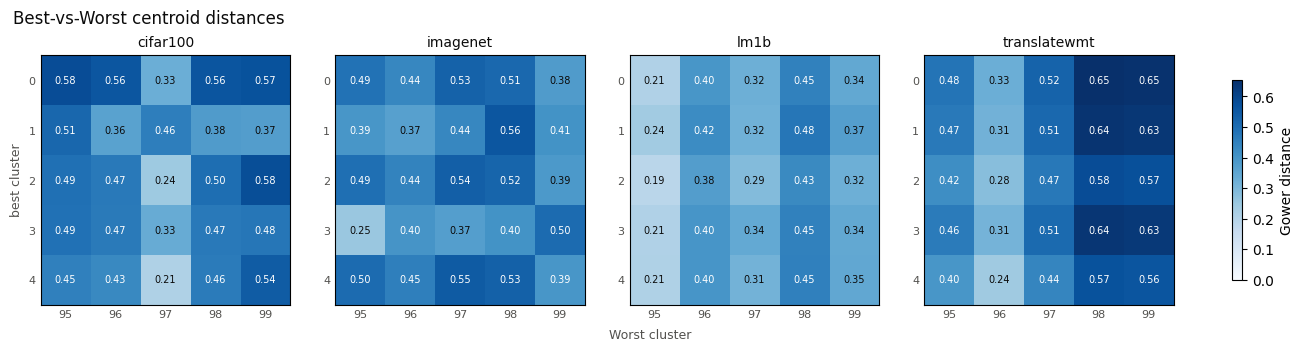

In [8]:
vmax = max(m.max() for m in submatrices.values())
fig, axes = plt.subplots(1, 4, figsize=(13, 3.4), constrained_layout=True)

for ax, scenario in zip(axes, MFPBENCH_SCENARIO_OPTIONS):
    matrix = submatrices[scenario]
    image = ax.imshow(matrix, cmap="Blues", vmin=0, vmax=vmax)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(
                j, i, f"{matrix[i, j]:.2f}",
                ha="center", va="center", fontsize=7,
                color="#ffffff" if matrix[i, j] > vmax * 0.6 else INK,
            )
    ax.set_title(SHORT[scenario], color=INK, fontsize=10)
    ax.set_xticks(range(matrix.shape[1]), [f"{c}" for c in range(100 - matrix.shape[1], 100)], fontsize=8, color=MUTED)
    ax.set_yticks(range(matrix.shape[0]), [f"{c}" for c in range(matrix.shape[0])], fontsize=8, color=MUTED)
    ax.tick_params(length=0)

axes[0].set_ylabel("best cluster", color=MUTED, fontsize=9)
fig.supxlabel("Worst cluster", color=MUTED, fontsize=9)
fig.colorbar(image, ax=axes, shrink=0.8, label="Gower distance")
fig.suptitle("Best-vs-Worst centroid distances", color=INK, fontsize=12, x=0.01, ha="left")
fig.savefig(REPO_ROOT / "benchmark_data/prior_data/mfpbench/cluster/best_vs_deceptive.png", dpi=700, bbox_inches="tight")
plt.show()